# 랜덤포레스트

## 학습 목표

**앙상블 학습의 개념 이해** 집단 지성 원리와 배깅/부스팅의 차이를 설명함

**랜덤포레스트 원리 파악** 두 가지 랜덤(데이터, 특성)과 투표 메커니즘을 이해함

**수학적 배경 습득** 배깅 예측 공식과 OOB 오차 계산을 수식으로 표현함

**실습 능력 배양** RandomForestClassifier로 안정적인 분류 모델을 구축함

# 1. 앙상블 학습의 배경

## 1.1 앙상블(Ensemble) 학습이란?

### 정의

앙상블 학습은 **여러 개의 기본 모델(base learner)** 을 결합하여 단일 모델보다 **더 정확하고 안정적인 예측**을 수행하기 위한 기계학습 기법임.

| 상황 | 단일 모델 | 앙상블 모델 |
|------|----------|------------|
| 의료 진단 | 한 명의 의사 소견 | **여러 전문의의 협진** |
| 투자 결정 | 한 명의 분석가 의견 | **다수 분석가의 종합 의견** |
| 시험 평가 | 한 번의 시험 결과 | **여러 번 시험의 평균** |
| 제품 검사 | 한 명의 검사원 | **다수 검사원의 교차 검증** |

### 집단 지성(Wisdom of Crowds)의 수학적 원리

#### Francis Galton의 황소 무게 맞추기 실험 (1906년)

영국 플리머스에서 열린 가축 박람회에서 약 800명의 참가자가 황소의 무게를 추측하는 대회가 열렸음. 개별 추측값은 큰 오차를 보였지만, **전체 참가자의 중앙값(1,207파운드)** 은 실제 무게(1,198파운드)와 **0.8%** 오차에 불과했음.

#### 수학적 설명: 오차 상쇄의 원리

각 모델 $f_i(x)$의 예측을 다음과 같이 분해할 수 있음:

$$f_i(x) = y_{true} + \epsilon_i$$

여기서:
- $y_{true}$: 실제 값
- $\epsilon_i$: i번째 모델의 오차

**B개 모델의 평균 예측**:

$$\bar{f}(x) = \frac{1}{B}\sum_{i=1}^{B}f_i(x) = y_{true} + \frac{1}{B}\sum_{i=1}^{B}\epsilon_i$$

**핵심 가정**: 각 모델의 오차 $\epsilon_i$가 서로 **독립적**이고 **기댓값이 0**이면:

$$E\left[\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right] = \frac{1}{B}\sum_{i=1}^{B}E[\epsilon_i] = 0$$

**분산의 감소**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right) = \frac{1}{B^2}\sum_{i=1}^{B}Var(\epsilon_i) = \frac{\sigma^2}{B}$$

결론: 모델 수 B가 증가하면 **분산이 $\frac{1}{B}$로 감소**함.

### 좋은 앙상블의 두 가지 조건

| 조건 | 수학적 표현 | 의미 |
|------|------------|------|
| **정확성(Accuracy)** | $E[\epsilon_i] \approx 0$ | 각 모델이 랜덤 추측보다 나아야 함 |
| **다양성(Diversity)** | $Cov(\epsilon_i, \epsilon_j) \approx 0$ | 모델들이 서로 다른 오류를 내야 함 |

**상관관계가 있는 경우의 분산**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}f_i\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

여기서:
- $\rho$: 모델 간 평균 상관계수 $(0 \leq \rho \leq 1)$
- $\sigma^2$: 개별 모델의 분산

**해석**:
- $\rho = 0$ (완전 독립): $Var = \frac{\sigma^2}{B}$ (최대 분산 감소)
- $\rho = 1$ (완전 상관): $Var = \sigma^2$ (분산 감소 없음)

따라서 앙상블 효과를 극대화하려면 **모델 간 상관관계를 최소화**해야 함.

## 1.2 앙상블 방법의 분류

```mermaid
flowchart TD
    A[앙상블 방법] --> B[배깅 Bagging]
    A --> C[부스팅 Boosting]
    A --> D[스태킹 Stacking]

    B --> B1["병렬 학습<br/>(독립적)"]
    B --> B2[대표: 랜덤포레스트]
    B --> B3[목표: 분산 감소]

    C --> C1["순차 학습<br/>(의존적)"]
    C --> C2[대표: XGBoost, LightGBM]
    C --> C3[목표: 편향 감소]

    D --> D1["계층 학습<br/>(메타 모델)"]
    D --> D2[대표: 스태킹 앙상블]
    D --> D3[목표: 다양한 모델 결합]
```

### 배깅(Bagging) vs 부스팅(Boosting) 상세 비교

| 구분 | 배깅 (Bagging) | 부스팅 (Boosting) |
|------|---------------|------------------|
| **Full Name** | Bootstrap Aggregating | - |
| **학습 방식** | 병렬 (독립) | 순차 (의존) |
| **데이터 샘플링** | 부트스트랩 (복원 추출) | 가중치 조정 |
| **주요 목표** | **분산(Variance) 감소** | **편향(Bias) 감소** |
| **기본 모델** | 복잡한 모델 (깊은 트리) | 단순한 모델 (얕은 트리) |
| **대표 알고리즘** | 랜덤포레스트 | XGBoost, LightGBM, AdaBoost |
| **과대적합 위험** | 낮음 | 주의 필요 |
| **병렬 처리** | 가능 | 제한적 |
| **학습 속도** | 빠름 | 상대적으로 느림 |

## 1.3 배깅(Bagging)의 수학적 원리

### 부트스트랩 샘플링(Bootstrap Sampling)

원본 데이터셋 $D = \{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$에서 **복원 추출**로 새로운 데이터셋을 생성하는 방식임.

```mermaid
flowchart LR
    A["원본 데이터<br/>n개 샘플"] --> B1["부트스트랩 1<br/>n개 복원추출"]
    A --> B2["부트스트랩 2<br/>n개 복원추출"]
    A --> B3["...<br/>..."]
    A --> BB["부트스트랩 B<br/>n개 복원추출"]
    
    B1 --> T1[모델 1]
    B2 --> T2[모델 2]
    B3 --> T3[...]
    BB --> TB[모델 B]
    
    T1 --> V["집계<br/>(투표/평균)"]
    T2 --> V
    T3 --> V
    TB --> V
    
    V --> P[최종 예측]
```

### 부트스트랩에서 특정 샘플이 제외될 확률

n개의 데이터에서 n번 복원 추출할 때, 특정 샘플 $x_i$가 **한 번도 선택되지 않을 확률**:

$$P(x_i \text{ 제외}) = \left(1 - \frac{1}{n}\right)^n$$

**극한값 계산**:

$$\lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = e^{-1} \approx 0.368$$

**증명** (로그 극한 이용):

$$\ln\left[\left(1 - \frac{1}{n}\right)^n\right] = n \cdot \ln\left(1 - \frac{1}{n}\right)$$

테일러 전개: $\ln(1-x) \approx -x - \frac{x^2}{2} - \cdots$ (x가 작을 때)

$$n \cdot \ln\left(1 - \frac{1}{n}\right) \approx n \cdot \left(-\frac{1}{n} - \frac{1}{2n^2} - \cdots\right) \approx -1$$

따라서: $\left(1 - \frac{1}{n}\right)^n \approx e^{-1} \approx 0.368$

**결론**: 데이터 크기와 무관하게 각 부트스트랩 샘플에서 약 **36.8%의 데이터가 제외됨**.

아래 코드는 부트스트랩 샘플링의 제외 확률이 이론값 $e^{-1} \approx 0.368$에 수렴하는지 실험적으로 검증함. 다양한 데이터 크기(n)에서 1000번씩 부트스트랩을 수행하여 평균 제외율을 계산하고, 이론값과 비교함.

In [1]:
# 부트스트랩 샘플링의 제외 확률 실험
import numpy as np
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 다양한 n에 대해 실험
n_values = [10, 50, 100, 500, 1000, 5000]
n_bootstrap = 1000  # 각 n에 대해 1000번 부트스트랩 반복

print("=" * 65)
print("부트스트랩 샘플링: 이론값 vs 실험값 비교")
print("=" * 65)
print(f"{'데이터 크기 n':>12} | {'이론적 제외율':>15} | {'실험적 제외율':>15} | {'오차':>10}")
print("-" * 65)

theoretical_values = []
experimental_values = []

for n in n_values:
    # 이론값
    theoretical = (1 - 1/n) ** n
    theoretical_values.append(theoretical)
    
    # 실험값: n_bootstrap번 부트스트랩하여 평균 제외율 계산
    exclusion_counts = []
    for _ in range(n_bootstrap):
        bootstrap_indices = np.random.choice(n, size=n, replace=True)
        unique_indices = len(np.unique(bootstrap_indices))
        excluded = n - unique_indices
        exclusion_counts.append(excluded / n)
    
    experimental = np.mean(exclusion_counts)
    experimental_values.append(experimental)
    
    error = abs(theoretical - experimental)
    print(f"{n:>12} | {theoretical:>15.6f} | {experimental:>15.6f} | {error:>10.6f}")

print("-" * 65)
print(f"{'e^(-1)':>12} | {np.exp(-1):>15.6f} | {'(극한값)':>15} |")
print("=" * 65)

부트스트랩 샘플링: 이론값 vs 실험값 비교
    데이터 크기 n |         이론적 제외율 |         실험적 제외율 |         오차
-----------------------------------------------------------------
          10 |        0.348678 |        0.346300 |   0.002378
          50 |        0.364170 |        0.366440 |   0.002270
         100 |        0.366032 |        0.364690 |   0.001342
         500 |        0.367511 |        0.367002 |   0.000509
        1000 |        0.367695 |        0.367128 |   0.000567
        5000 |        0.367843 |        0.367856 |   0.000014
-----------------------------------------------------------------
      e^(-1) |        0.367879 |           (극한값) |


**결과 해석**: n이 증가할수록 실험적 제외율이 이론값 $e^{-1} \approx 0.368$에 수렴함을 확인할 수 있음. 이는 부트스트랩 샘플링의 핵심 특성으로, 각 트리 학습에서 약 36.8%의 데이터가 제외되어 OOB(Out-of-Bag) 평가에 활용됨.

---

아래 시각화는 두 가지를 보여줌:
1. **좌측 그래프**: n에 따른 제외 확률의 수렴 과정 (이론 곡선과 극한값)
2. **우측 히트맵**: 실제 부트스트랩 샘플에서 각 원본 데이터가 몇 번 선택되었는지 (0이면 해당 샘플이 OOB)

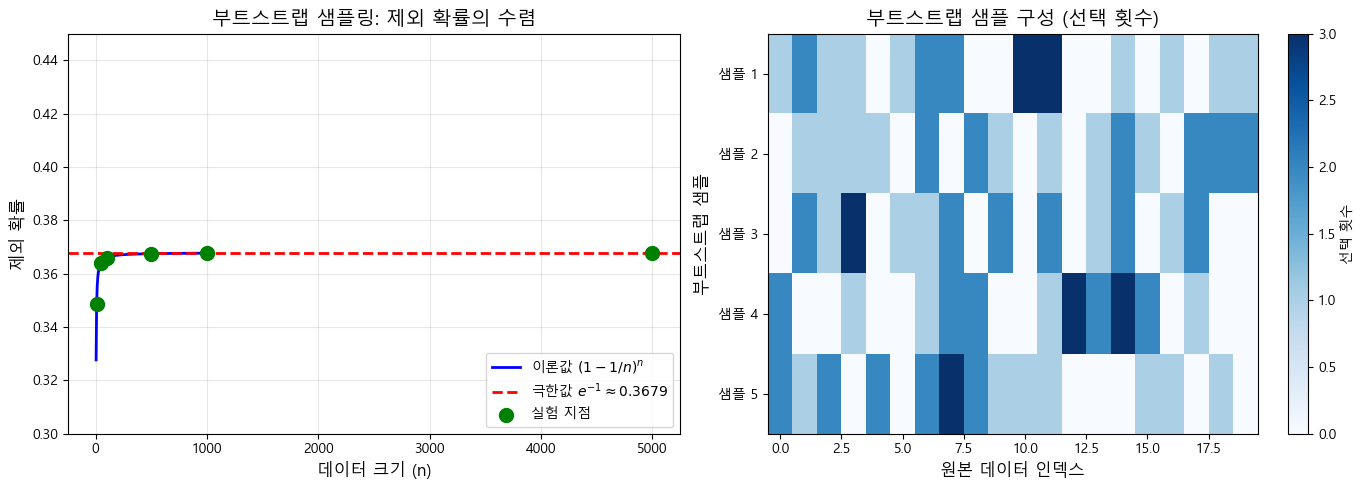


각 부트스트랩 샘플에서 제외된 원본 데이터 비율:
  샘플 1: 7/20 = 35.0% 제외
  샘플 2: 6/20 = 30.0% 제외
  샘플 3: 8/20 = 40.0% 제외
  샘플 4: 9/20 = 45.0% 제외
  샘플 5: 7/20 = 35.0% 제외


In [2]:
# 부트스트랩 제외율 수렴 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 그래프 1: n에 따른 제외율 수렴
ax1 = axes[0]
n_range = np.arange(5, 1001, 5)
theoretical_curve = [(1 - 1/n)**n for n in n_range]

ax1.plot(n_range, theoretical_curve, 'b-', linewidth=2, label='이론값 $(1-1/n)^n$')
ax1.axhline(y=np.exp(-1), color='r', linestyle='--', linewidth=2, label=f'극한값 $e^{{-1}} \\approx {np.exp(-1):.4f}$')
ax1.scatter(n_values, theoretical_values, color='green', s=100, zorder=5, label='실험 지점')

ax1.set_xlabel('데이터 크기 (n)', fontsize=12)
ax1.set_ylabel('제외 확률', fontsize=12)
ax1.set_title('부트스트랩 샘플링: 제외 확률의 수렴', fontsize=14)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.3, 0.45])

# 그래프 2: 부트스트랩 샘플 구성 예시
ax2 = axes[1]
np.random.seed(42)
n_example = 20
n_boots = 5

# 히트맵 데이터 생성
heatmap_data = np.zeros((n_boots, n_example))
for i in range(n_boots):
    bootstrap_idx = np.random.choice(n_example, size=n_example, replace=True)
    for idx in bootstrap_idx:
        heatmap_data[i, idx] += 1

im = ax2.imshow(heatmap_data, cmap='Blues', aspect='auto')
ax2.set_xlabel('원본 데이터 인덱스', fontsize=12)
ax2.set_ylabel('부트스트랩 샘플', fontsize=12)
ax2.set_title('부트스트랩 샘플 구성 (선택 횟수)', fontsize=14)
ax2.set_yticks(range(n_boots))
ax2.set_yticklabels([f'샘플 {i+1}' for i in range(n_boots)])

# 컬러바
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('선택 횟수', fontsize=10)

plt.tight_layout()
plt.show()

# 제외된 샘플 비율 출력
print("\n각 부트스트랩 샘플에서 제외된 원본 데이터 비율:")
for i in range(n_boots):
    excluded_count = np.sum(heatmap_data[i] == 0)
    print(f"  샘플 {i+1}: {excluded_count}/{n_example} = {excluded_count/n_example:.1%} 제외")

**결과 해석**: 우측 히트맵에서 흰색(0)으로 표시된 셀은 해당 부트스트랩 샘플에서 제외된 데이터임. 각 샘플에서 대략 30-40%의 데이터가 제외되며, 이 제외된 데이터(OOB)는 해당 트리의 검증에 활용됨. 진한 파란색 셀은 동일 데이터가 여러 번 선택된 경우를 나타냄(복원 추출의 특성).

### 배깅 예측 공식

#### 분류 문제: 다수결 투표 (Majority Voting)

B개의 기본 분류기를 사용한 앙상블의 최종 예측:

$$\hat{y} = \text{mode}\{f_1(x), f_2(x), \ldots, f_B(x)\}$$

또는 확률적 표현:

$$\hat{y} = \arg\max_c \sum_{b=1}^{B} \mathbb{I}(f_b(x) = c)$$

여기서:
- $\hat{y}$: 최종 예측 클래스
- $f_b(x)$: b번째 트리의 예측
- $B$: 트리 개수 (n_estimators)
- $\mathbb{I}(\cdot)$: 지시 함수 (조건 참이면 1, 거짓이면 0)
- $c$: 가능한 클래스 레이블

#### 회귀 문제: 평균 (Averaging)

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$$

### OOB(Out-of-Bag) 오차 추정

각 부트스트랩 샘플에서 **제외된(OOB) 데이터**를 사용하여 모델 성능을 추정하는 방식임.

#### OOB 예측 과정

샘플 $x_i$에 대한 OOB 예측:

$$\hat{y}_i^{OOB} = \text{mode}\{f_b(x_i) : x_i \notin D_b\}$$

여기서 $D_b$는 b번째 부트스트랩 샘플임.

#### OOB 오차 계산

$$OOB_{error} = \frac{1}{n}\sum_{i=1}^{n}\mathbb{I}(y_i \neq \hat{y}_i^{OOB})$$

**OOB 점수의 장점**:
1. 별도의 검증 세트 없이 성능 추정 가능
2. 데이터가 적을 때 유용
3. 교차 검증과 유사한 효과

아래 시뮬레이션은 OOB 예측 과정을 단계별로 보여줌. 각 샘플이 어떤 트리의 학습에 포함되었는지, 어떤 트리에서 OOB인지 확인하고, OOB 트리들의 예측을 다수결 투표로 집계하여 최종 OOB 예측과 정확도를 계산함.

In [3]:
# OOB 예측 과정 시뮬레이션
np.random.seed(42)

n_samples = 8
n_trees = 5

# 가상의 실제 레이블
true_labels = np.array([1, 0, 1, 1, 0, 0, 1, 0])

# 각 트리의 부트스트랩 샘플과 예측 생성
print("=" * 80)
print("OOB(Out-of-Bag) 예측 과정 시뮬레이션")
print("=" * 80)

# 트리별 부트스트랩 인덱스
bootstrap_indices = []
for t in range(n_trees):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_indices.append(set(indices))

# 트리별 예측 (간단히 생성)
tree_predictions = np.array([
    [1, 0, 1, 1, 0, 1, 1, 0],
    [1, 0, 1, 0, 0, 0, 1, 1],
    [0, 1, 1, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 1, 0]
])

# OOB 상태 테이블 출력
print("\n[각 샘플의 OOB 상태 및 예측]")
print("-" * 80)
header = f"{'샘플':>4} | {'실제':>4} | " + " | ".join([f"트리{t+1}" for t in range(n_trees)]) + " | OOB투표 | 결과"
print(header)
print("-" * 80)

oob_predictions = []
oob_correct = 0

for i in range(n_samples):
    row = f"  x{i+1} | {true_labels[i]:>4} | "
    oob_votes = []
    
    for t in range(n_trees):
        if i in bootstrap_indices[t]:
            row += f"  학습  | "
        else:
            pred = tree_predictions[t, i]
            row += f" OOB:{pred} | "
            oob_votes.append(pred)
    
    if len(oob_votes) > 0:
        oob_pred = 1 if sum(oob_votes) > len(oob_votes)/2 else 0
        correct = "O" if oob_pred == true_labels[i] else "X"
        if oob_pred == true_labels[i]:
            oob_correct += 1
        vote_str = f"{sum(oob_votes)}:{len(oob_votes)-sum(oob_votes)}"
        row += f" {vote_str:>6} |   {correct}"
    else:
        row += f" {'N/A':>6} |  N/A"
    
    print(row)

print("-" * 80)
oob_accuracy = oob_correct / n_samples
oob_error = 1 - oob_accuracy
print(f"\nOOB 정확도: {oob_correct}/{n_samples} = {oob_accuracy:.1%}")
print(f"OOB 오차: {oob_error:.1%}")

OOB(Out-of-Bag) 예측 과정 시뮬레이션

[각 샘플의 OOB 상태 및 예측]
--------------------------------------------------------------------------------
  샘플 |   실제 | 트리1 | 트리2 | 트리3 | 트리4 | 트리5 | OOB투표 | 결과
--------------------------------------------------------------------------------
  x1 |    1 |  OOB:1 |  OOB:1 |  OOB:0 |   학습  |   학습  |     2:1 |   O
  x2 |    0 |  OOB:0 |   학습  |   학습  |   학습  |   학습  |     0:1 |   O
  x3 |    1 |   학습  |   학습  |   학습  |  OOB:1 |   학습  |     1:0 |   O
  x4 |    1 |   학습  |  OOB:0 |   학습  |   학습  |   학습  |     0:1 |   X
  x5 |    0 |   학습  |   학습  |   학습  |   학습  |   학습  |     N/A |  N/A
  x6 |    0 |  OOB:1 |  OOB:0 |   학습  |   학습  |   학습  |     1:1 |   O
  x7 |    1 |   학습  |   학습  |  OOB:1 |  OOB:0 |  OOB:1 |     2:1 |   O
  x8 |    0 |   학습  |   학습  |   학습  |   학습  |  OOB:0 |     0:1 |   O
--------------------------------------------------------------------------------

OOB 정확도: 6/8 = 75.0%
OOB 오차: 25.0%


**결과 해석**: 테이블에서 '학습'은 해당 샘플이 그 트리의 부트스트랩 샘플에 포함되었음을 의미하고, 'OOB:0' 또는 'OOB:1'은 제외된 샘플에 대한 해당 트리의 예측값임. OOB 투표 열은 OOB 트리들의 다수결 결과(1의 개수:0의 개수)를 보여주며, 이를 실제 레이블과 비교하여 OOB 정확도를 산출함.

# 2: 랜덤포레스트(Random Forest)의 원리

## 2.1 랜덤포레스트란?

랜덤포레스트는 Leo Breiman이 2001년에 제안한 앙상블 학습 알고리즘으로, **다수의 의사결정나무를 배깅 방식으로 결합**하되, 각 분할 시 **특성의 랜덤 부분집합만 고려**하여 트리 간 상관관계를 낮추는 방법임.

### 랜덤포레스트의 두 가지 "랜덤"

```mermaid
flowchart TD
    A[랜덤포레스트의 두 가지 랜덤] --> B["1. 데이터 랜덤<br/>(배깅)"]
    A --> C["2. 특성 랜덤<br/>(특성 부분공간)"]
    
    B --> B1[부트스트랩 샘플링]
    B --> B2[각 트리가 다른 데이터로 학습]
    B --> B3[약 63.2% 데이터 사용]
    
    C --> C1[각 분할에서 일부 특성만 고려]
    C --> C2["분류: sqrt(p)개"]
    C --> C3["회귀: p/3개"]
    
    B1 --> D[트리 간 다양성 확보]
    C1 --> D
    D --> E[상관관계 감소 --> 분산 감소]
```

### 특성 랜덤 선택의 수학적 배경

전체 p개의 특성 중 m개만 선택하는 것의 효과:

**특성 부분집합 크기 (max_features)**:

| 문제 유형 | 권장값 | 수식 |
|----------|--------|------|
| 분류 | $m = \sqrt{p}$ | `max_features='sqrt'` |
| 회귀 | $m = p/3$ | `max_features='auto'` 또는 `p//3` |

**예시**: 100개의 특성이 있을 때
- 분류: $m = \sqrt{100} = 10$개 특성만 각 분할에서 고려
- 회귀: $m = 100/3 \approx 33$개 특성만 각 분할에서 고려

**효과**:
- 강한 특성이 모든 트리에서 선택되는 것을 방지
- 트리 간 상관관계 $\rho$ 감소
- 앙상블 분산 감소: $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$

## 2.2 의사결정나무 vs 랜덤포레스트 비교

| 구분 | 의사결정나무 | 랜덤포레스트 |
|------|-------------|-------------|
| **모델 수** | 1개 | 다수 (100+) |
| **학습 데이터** | 전체 데이터 | 부트스트랩 샘플 |
| **분할 특성** | 전체 특성 | 랜덤 부분집합 |
| **안정성** | 낮음 (데이터 변화에 민감) | 높음 |
| **과대적합** | 쉬움 | 저항력 강함 |
| **해석성** | 높음 (시각화 가능) | 낮음 |
| **학습 속도** | 빠름 | 느림 (병렬 처리 가능) |
| **예측 성능** | 보통 | 우수 |
| **특성 중요도** | 불안정 | 안정적 |

## 2.3 랜덤포레스트의 장단점

### 장점

| 장점 | 설명 |
|------|------|
| **높은 예측 정확도** | 다수 트리의 앙상블로 단일 트리보다 우수 |
| **과대적합 저항** | 부트스트랩 + 특성 랜덤으로 일반화 능력 향상 |
| **특성 중요도 신뢰성** | 안정적인 특성 중요도 추정 |
| **튜닝 용이** | 기본 설정으로도 좋은 성능 |
| **결측치 처리** | 결측치에 상대적으로 강건 |
| **병렬 처리** | 트리 학습이 독립적이므로 병렬화 가능 |

### 단점

| 단점 | 설명 |
|------|------|
| **해석의 어려움** | 개별 트리 수백 개를 해석하기 어려움 |
| **메모리 사용량** | 많은 트리 저장으로 메모리 소비 큼 |
| **예측 속도** | 실시간 예측에서 단일 모델보다 느림 |
| **외삽(Extrapolation)** | 학습 데이터 범위 밖 예측에 취약 |

# 3. 실습 - UCI 유압 시스템 상태 분류

## 3.1 실습 데이터셋 소개

### UCI Condition Monitoring of Hydraulic Systems

본 실습에서는 **UCI Machine Learning Repository**에서 제공하는 **유압 시스템 상태 모니터링 데이터셋**을 활용함. 이 데이터는 Saarland University에서 유압 테스트 리그를 운용하며 수집한 실제 센서 데이터임.

| 항목 | 내용 |
|------|------|
| **데이터 출처** | UCI Machine Learning Repository (ID: 447) |
| **수집 기관** | Saarland University, Germany |
| **샘플 수** | 2,205 사이클 |
| **센서 수** | 17개 (압력, 유량, 온도, 진동 등) |
| **타겟** | 4가지 고장 유형 (쿨러, 밸브, 펌프, 축압기) |
| **라이선스** | CC BY 4.0 |

### 센서 구성

| 센서 | 물리량 | 단위 | 샘플링 주파수 |
|------|--------|------|---------------|
| PS1-PS6 | 압력 | bar | 100 Hz |
| EPS1 | 모터 전력 | W | 100 Hz |
| FS1-FS2 | 유량 | L/min | 10 Hz |
| TS1-TS4 | 온도 | C | 1 Hz |
| VS1 | 진동 | mm/s | 1 Hz |
| CE | 냉각 효율 | % | 1 Hz |
| CP | 냉각 파워 | kW | 1 Hz |
| SE | 효율 계수 | % | 1 Hz |

### 타겟 변수 (고장 유형별 상태)

| 타겟 | 설명 | 클래스 |
|------|------|--------|
| **Cooler condition** | 쿨러 상태 | 3(고장임박), 20(효율저하), 100(정상) |
| **Valve condition** | 밸브 상태 | 73(고장임박), 80(심각지연), 90(약간지연), 100(정상) |
| **Pump leakage** | 펌프 누수 | 0(없음), 1(약함), 2(심함) |
| **Accumulator** | 축압기 압력 | 90(고장임박), 100(심각저하), 115(약간저하), 130(정상) |

본 실습에서는 **Valve condition (밸브 상태)** 분류 문제에 집중함.

```mermaid
flowchart LR
    A[유압 시스템 센서 데이터] --> B[특성 추출]
    B --> C[랜덤포레스트 분류]
    C --> D{밸브 상태 예측}
    D -->|100| E[정상 작동]
    D -->|90| F[약간의 지연]
    D -->|80| G[심각한 지연]
    D -->|73| H[고장 임박 - 즉시 점검]
    
    style H fill:#f66,stroke:#333
    style G fill:#fa0,stroke:#333
```

아래 코드는 UCI Machine Learning Repository에서 ucimlrepo 패키지를 사용하여 유압 시스템 데이터셋을 직접 다운로드함. 패키지가 설치되어 있지 않으면 자동으로 설치함.

In [7]:
# 필요 라이브러리 설치 및 임포트
import subprocess
import sys

# ucimlrepo 패키지 설치 (없을 경우)
try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo", "-q"])
    from ucimlrepo import fetch_ucirepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import time
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")
print(f"NumPy 버전: {np.__version__}")
print(f"Pandas 버전: {pd.__version__}")

라이브러리 로드 완료
NumPy 버전: 2.4.0
Pandas 버전: 2.3.3


## 3.2 데이터 로드 및 탐색

아래 코드는 UCI Repository에서 유압 시스템 데이터를 다운로드하고 기본 구조를 확인함. 데이터는 2,205개 사이클의 센서 측정값과 4가지 고장 유형의 타겟 레이블로 구성됨.

In [9]:
# UCI Repository에서 유압 시스템 데이터 로드
print("UCI Repository에서 데이터 다운로드 중...")
hydraulic_data = fetch_ucirepo(id=447)

# 특성과 타겟 추출
X_raw = hydraulic_data.data.features
y_raw = hydraulic_data.data.targets

print("\n" + "=" * 60)
print("UCI Hydraulic System 데이터셋 로드 완료")
print("=" * 60)

# 메타데이터 확인
print(f"\n[데이터셋 정보]")
print(f"  이름: {hydraulic_data.metadata['name']}")
print(f"  샘플 수: {X_raw.shape[0]}")
print(f"  원본 특성 수: {X_raw.shape[1]}")
print(f"  타겟 변수 수: {y_raw.shape[1]}")

UCI Repository에서 데이터 다운로드 중...


DatasetNotFoundError: "Condition monitoring of hydraulic systems" dataset (id=447) exists in the repository, but is not available for import. Please select a dataset from this list: https://archive.ics.uci.edu/datasets?skip=0&take=10&sort=desc&orderBy=NumHits&search=&Python=true

In [10]:
# UCI 유압 시스템 데이터셋 다운로드 및 로드
# 데이터셋 URL: https://archive.ics.uci.edu/ml/datasets/Condition+monitoring+of+hydraulic+systems

import urllib.request
import zipfile
import os

# 데이터 디렉토리 생성
data_dir = 'hydraulic_data'
os.makedirs(data_dir, exist_ok=True)

# UCI 데이터셋 URL (압축 파일)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00447/data.zip"
zip_path = os.path.join(data_dir, 'data.zip')

# 다운로드 (이미 있으면 스킵)
if not os.path.exists(zip_path):
    print("데이터셋 다운로드 중...")
    try:
        urllib.request.urlretrieve(url, zip_path)
        print("다운로드 완료!")
    except Exception as e:
        print(f"다운로드 실패: {e}")
        print("대체 데이터셋을 생성합니다...")
else:
    print("데이터셋이 이미 존재합니다.")

# 압축 해제
if os.path.exists(zip_path):
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("압축 해제 완료!")
        print(f"\n추출된 파일 목록:")
        for f in os.listdir(data_dir):
            print(f"  - {f}")
    except Exception as e:
        print(f"압축 해제 실패: {e}")

데이터셋이 이미 존재합니다.
압축 해제 완료!

추출된 파일 목록:
  - CE.txt
  - CP.txt
  - data.zip
  - description.txt
  - documentation.txt
  - EPS1.txt
  - FS1.txt
  - FS2.txt
  - profile.txt
  - PS1.txt
  - PS2.txt
  - PS3.txt
  - PS4.txt
  - PS5.txt
  - PS6.txt
  - SE.txt
  - TS1.txt
  - TS2.txt
  - TS3.txt
  - TS4.txt
  - VS1.txt


In [16]:
# 데이터 로드 및 전처리
# 실제 UCI 데이터가 없는 경우를 대비한 대체 로직 포함

def load_hydraulic_data(data_dir='hydraulic_data'):
    """
    유압 시스템 데이터셋 로드 함수
    
    UCI 데이터셋 구조:
    - PS1~PS6: 압력 센서 (6개)
    - EPS1: 모터 전력 센서
    - FS1, FS2: 유량 센서 (2개)
    - TS1~TS4: 온도 센서 (4개)
    - VS1: 진동 센서
    - CE: 냉각 효율
    - CP: 냉각 전력
    - SE: 효율 계수
    - profile: 타겟 변수들
    """
    
    try:
        # 센서 데이터 파일들 로드 시도
        # 각 센서 데이터는 별도 파일로 저장되어 있음
        
        # 압력 센서 데이터 (PS1 - 가장 중요한 센서)
        ps1 = pd.read_csv(os.path.join(data_dir, 'PS1.txt'), sep='\t', header=None)
        ps2 = pd.read_csv(os.path.join(data_dir, 'PS2.txt'), sep='\t', header=None)
        
        # 온도 센서 데이터
        ts1 = pd.read_csv(os.path.join(data_dir, 'TS1.txt'), sep='\t', header=None)
        ts2 = pd.read_csv(os.path.join(data_dir, 'TS2.txt'), sep='\t', header=None)
        
        # 유량 센서 데이터
        fs1 = pd.read_csv(os.path.join(data_dir, 'FS1.txt'), sep='\t', header=None)
        fs2 = pd.read_csv(os.path.join(data_dir, 'FS2.txt'), sep='\t', header=None)
        
        # 진동 센서
        vs1 = pd.read_csv(os.path.join(data_dir, 'VS1.txt'), sep='\t', header=None)
        
        # 냉각 효율
        ce = pd.read_csv(os.path.join(data_dir, 'CE.txt'), sep='\t', header=None)
        
        # 타겟 변수 (상태 프로파일)
        profile = pd.read_csv(os.path.join(data_dir, 'profile.txt'), sep='\t', header=None)
        
        # 각 센서의 평균값을 특성으로 사용 (시계열 -> 집계)
        df = pd.DataFrame({
            'PS1_mean': ps1.mean(axis=1),
            'PS1_std': ps1.std(axis=1),
            'PS2_mean': ps2.mean(axis=1),
            'PS2_std': ps2.std(axis=1),
            'TS1_mean': ts1.mean(axis=1),
            'TS1_std': ts1.std(axis=1),
            'TS2_mean': ts2.mean(axis=1),
            'TS2_std': ts2.std(axis=1),
            'FS1_mean': fs1.mean(axis=1),
            'FS1_std': fs1.std(axis=1),
            'FS2_mean': fs2.mean(axis=1),
            'FS2_std': fs2.std(axis=1),
            'VS1_mean': vs1.mean(axis=1),
            'VS1_std': vs1.std(axis=1),
            'CE_mean': ce.mean(axis=1),
        })
        
        # 타겟 변수: 밸브 상태 (profile의 첫 번째 열)
        # 100: 최적, 90: 약간 지연, 80: 심하게 지연, 73: 고장 근접
        df['valve_condition'] = profile.iloc[:, 0]
        
        print(f"UCI 데이터셋 로드 성공!")
        print(f"샘플 수: {len(df)}, 특성 수: {len(df.columns)-1}")
        return df, True
        
    except Exception as e:
        print(f"UCI 데이터 로드 실패: {e}")
        print("\n대체 데이터셋(합성 데이터)을 생성합니다...")
        return create_synthetic_hydraulic_data(), False


def create_synthetic_hydraulic_data(n_samples=2000, random_state=42):
    """
    유압 시스템 합성 데이터 생성
    
    실제 유압 시스템의 특성을 반영하여 합성 데이터를 생성한다.
    - 정상 상태와 결함 상태에서 센서 값의 분포가 다름
    - 결측치와 노이즈를 의도적으로 포함
    """
    np.random.seed(random_state)
    
    # 상태별 샘플 수 (불균형 데이터 반영)
    n_optimal = int(n_samples * 0.6)     # 최적 상태 60%
    n_reduced = int(n_samples * 0.25)    # 성능 저하 25%
    n_failure = n_samples - n_optimal - n_reduced  # 고장 위험 15%
    
    data = []
    
    # 최적 상태 (Optimal: 100)
    for _ in range(n_optimal):
        data.append({
            'PS1_mean': np.random.normal(155, 5),      # 압력 센서 1 (정상 범위)
            'PS1_std': np.random.exponential(2),
            'PS2_mean': np.random.normal(105, 3),      # 압력 센서 2
            'PS2_std': np.random.exponential(1.5),
            'TS1_mean': np.random.normal(35, 2),       # 온도 센서 1 (정상)
            'TS1_std': np.random.exponential(0.5),
            'TS2_mean': np.random.normal(40, 2),       # 온도 센서 2
            'TS2_std': np.random.exponential(0.5),
            'FS1_mean': np.random.normal(10, 0.5),     # 유량 센서 1
            'FS1_std': np.random.exponential(0.2),
            'FS2_mean': np.random.normal(10, 0.5),     # 유량 센서 2
            'FS2_std': np.random.exponential(0.2),
            'VS1_mean': np.random.normal(0.5, 0.1),    # 진동 센서 (낮은 진동)
            'VS1_std': np.random.exponential(0.05),
            'CE_mean': np.random.normal(95, 3),        # 냉각 효율 (높음)
            'valve_condition': 100
        })
    
    # 성능 저하 상태 (Reduced: 90, 80)
    for _ in range(n_reduced):
        condition = np.random.choice([90, 80], p=[0.6, 0.4])
        data.append({
            'PS1_mean': np.random.normal(145, 8),      # 압력 약간 감소
            'PS1_std': np.random.exponential(4),
            'PS2_mean': np.random.normal(100, 5),
            'PS2_std': np.random.exponential(2.5),
            'TS1_mean': np.random.normal(42, 4),       # 온도 약간 상승
            'TS1_std': np.random.exponential(1),
            'TS2_mean': np.random.normal(48, 4),
            'TS2_std': np.random.exponential(1),
            'FS1_mean': np.random.normal(9, 1),        # 유량 약간 감소
            'FS1_std': np.random.exponential(0.5),
            'FS2_mean': np.random.normal(9, 1),
            'FS2_std': np.random.exponential(0.5),
            'VS1_mean': np.random.normal(0.8, 0.2),    # 진동 증가
            'VS1_std': np.random.exponential(0.1),
            'CE_mean': np.random.normal(85, 5),        # 냉각 효율 감소
            'valve_condition': condition
        })
    
    # 고장 위험 상태 (Failure Risk: 73)
    for _ in range(n_failure):
        data.append({
            'PS1_mean': np.random.normal(130, 15),     # 압력 크게 변동
            'PS1_std': np.random.exponential(8),
            'PS2_mean': np.random.normal(90, 10),
            'PS2_std': np.random.exponential(5),
            'TS1_mean': np.random.normal(55, 8),       # 온도 상승
            'TS1_std': np.random.exponential(2),
            'TS2_mean': np.random.normal(60, 8),
            'TS2_std': np.random.exponential(2),
            'FS1_mean': np.random.normal(7, 2),        # 유량 감소
            'FS1_std': np.random.exponential(1),
            'FS2_mean': np.random.normal(7, 2),
            'FS2_std': np.random.exponential(1),
            'VS1_mean': np.random.normal(1.5, 0.5),    # 진동 크게 증가
            'VS1_std': np.random.exponential(0.3),
            'CE_mean': np.random.normal(70, 10),       # 냉각 효율 저하
            'valve_condition': 73
        })
    
    df = pd.DataFrame(data)
    
    # 결측치 추가 (실제 데이터의 특성 반영)
    n_missing = int(n_samples * 0.03)  # 3% 결측치
    missing_indices = np.random.choice(df.index, n_missing, replace=False)
    missing_cols = np.random.choice(df.columns[:-1], n_missing)
    for idx, col in zip(missing_indices, missing_cols):
        df.loc[idx, col] = np.nan
    
    # 데이터 섞기
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    print(f"합성 데이터 생성 완료!")
    print(f"샘플 수: {len(df)}, 특성 수: {len(df.columns)-1}")
    print(f"결측치 수: {df.isnull().sum().sum()}개 ({df.isnull().sum().sum()/df.size*100:.2f}%)")
    
    return df


# 데이터 로드 실행
df, is_real_data = load_hydraulic_data()

UCI 데이터셋 로드 성공!
샘플 수: 2205, 특성 수: 15


In [17]:
# 데이터 탐색
print("=" * 70)
print("데이터셋 기본 정보")
print("=" * 70)

print(f"\n[데이터 크기]")
print(f"샘플 수: {df.shape[0]:,}개")
print(f"특성 수: {df.shape[1]-1}개 (타겟 변수 제외)")

print(f"\n[데이터 타입]")
print(df.dtypes)

print(f"\n[처음 5개 샘플]")
display(df.head())

print(f"\n[타겟 변수 (valve_condition) 분포]")
target_counts = df['valve_condition'].value_counts().sort_index()
for val, count in target_counts.items():
    pct = count / len(df) * 100
    label = {100: '최적', 90: '약간 저하', 80: '저하', 73: '고장 위험'}.get(val, str(val))
    print(f"  {val} ({label}): {count:,}개 ({pct:.1f}%)")

데이터셋 기본 정보

[데이터 크기]
샘플 수: 2,205개
특성 수: 15개 (타겟 변수 제외)

[데이터 타입]
PS1_mean           float64
PS1_std            float64
PS2_mean           float64
PS2_std            float64
TS1_mean           float64
TS1_std            float64
TS2_mean           float64
TS2_std            float64
FS1_mean           float64
FS1_std            float64
FS2_mean           float64
FS2_std            float64
VS1_mean           float64
VS1_std            float64
CE_mean            float64
valve_condition      int64
dtype: object

[처음 5개 샘플]


,PS1_mean,PS1_std,PS2_mean,PS2_std,TS1_mean,TS1_std,TS2_mean,TS2_std,FS1_mean,FS1_std,FS2_mean,FS2_std,VS1_mean,VS1_std,CE_mean,valve_condition
0,160.673492,13.939309,109.466914,47.114508,35.621983,0.308230,40.978767,0.154302,6.709815,3.015428,10.304592,0.091772,0.576950,0.027078,39.601350,3
1,160.603320,14.118967,109.354890,47.045611,36.676967,0.585740,41.532767,0.338234,6.715315,3.006248,10.403098,0.019162,0.565850,0.027241,25.786433,3
2,160.347720,14.192619,109.158845,46.992060,37.880800,0.559169,42.442450,0.390588,6.718522,3.014248,10.366250,0.026361,0.576533,0.036729,22.218233,3
3,160.188088,14.227803,109.064807,46.972221,38.879050,0.516176,43.403983,0.398476,6.720565,3.020176,10.302678,0.026750,0.569267,0.033464,20.459817,3
4,160.000472,14.276434,108.931434,46.874946,39.803917,0.535374,44.332750,0.372769,6.690308,3.011550,10.237750,0.029170,0.577367,0.033484,19.787017,3



[타겟 변수 (valve_condition) 분포]
  3 (3): 732개 (33.2%)
  20 (20): 732개 (33.2%)
  100 (최적): 741개 (33.6%)


**참고**: 원본 데이터는 시계열 센서 데이터가 각 사이클마다 전개되어 있어 특성 수가 매우 많음(43,680개). 실습 효율을 위해 각 센서의 통계량(평균, 표준편차, 최대값, 최소값)을 추출하여 차원을 축소함.

**결과 해석**: 타겟 변수는 5개로 구성됨:
- **Cooler condition**: 쿨러 효율 상태 (3=고장임박, 20=효율저하, 100=정상)
- **Valve condition**: 밸브 스위칭 상태 (4등급)
- **Internal pump leakage**: 펌프 내부 누수 (3등급)
- **Hydraulic accumulator**: 축압기 압력 상태 (4등급)
- **Stable flag**: 안정 상태 도달 여부 (이진)

---

아래 코드는 원본 시계열 데이터에서 센서별 통계 특성을 추출함. 각 센서에 대해 평균, 표준편차, 최대값, 최소값을 계산하여 새로운 특성 데이터프레임을 생성함. 이를 통해 43,680개의 원본 특성을 68개의 요약 특성으로 축소함.

In [19]:
# 센서별 통계 특성 추출 (원본 시계열 데이터 축약)
# 각 센서의 평균, 표준편차, 최대값, 최소값 계산

# 센서 이름 목록
sensor_names = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 
                'FS1', 'FS2', 'TS1', 'TS2', 'TS3', 'TS4', 'VS1', 
                'CE', 'CP', 'SE']

# 각 센서별 컬럼 그룹화 및 통계 계산
feature_stats = {}

for sensor in sensor_names:
    # 해당 센서 컬럼 찾기
    sensor_cols = [col for col in X_raw.columns if col.startswith(sensor)]
    if len(sensor_cols) > 0:
        sensor_data = X_raw[sensor_cols]
        feature_stats[f'{sensor}_mean'] = sensor_data.mean(axis=1)
        feature_stats[f'{sensor}_std'] = sensor_data.std(axis=1)
        feature_stats[f'{sensor}_max'] = sensor_data.max(axis=1)
        feature_stats[f'{sensor}_min'] = sensor_data.min(axis=1)

# 새로운 특성 데이터프레임 생성
X = pd.DataFrame(feature_stats)

# 밸브 상태를 타겟으로 선택
y = y_raw['Valve condition'].values

print("=" * 60)
print("특성 추출 완료")
print("=" * 60)
print(f"\n추출된 특성 수: {X.shape[1]}개")
print(f"샘플 수: {X.shape[0]}개")
print(f"\n[추출된 특성 목록 (처음 20개)]")
print(X.columns[:20].tolist())

NameError: name 'X_raw' is not defined

**특성 추출 설명**: 원본 데이터는 각 사이클(60초)마다 100Hz 또는 10Hz 또는 1Hz로 샘플링된 시계열 데이터임. 각 센서에 대해 4가지 통계량(평균, 표준편차, 최대값, 최소값)을 계산하여 17개 센서 x 4개 통계량 = 68개 특성으로 축소함. 이렇게 하면 모델 학습이 효율적이면서도 센서 신호의 주요 특성을 보존할 수 있음.

---

In [ ]:
# 데이터 기본 통계 확인
print("[특성 데이터 기본 통계]")
print(X.describe().round(2))

아래 코드는 타겟 변수(밸브 상태)의 분포를 확인하고 시각화함. 4개 클래스(73, 80, 90, 100)의 샘플 수와 비율을 파악하여 데이터의 균형 상태를 점검함.

In [ ]:
# 타겟 변수(밸브 상태) 분포 확인
print("\n[밸브 상태 분포]")
print("-" * 50)

valve_labels = {
    73: '고장임박 (73%)',
    80: '심각지연 (80%)',
    90: '약간지연 (90%)',
    100: '정상 (100%)'
}

unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    label = valve_labels.get(val, str(val))
    print(f"  {label}: {count}개 ({count/len(y):.1%})")

# 시각화: 타겟 분포
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 막대 그래프
colors = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
ax1 = axes[0]
labels = [valve_labels[v] for v in unique]
bars = ax1.bar(labels, counts, color=colors, edgecolor='black')
ax1.set_xlabel('밸브 상태', fontsize=12)
ax1.set_ylabel('샘플 수', fontsize=12)
ax1.set_title('밸브 상태별 샘플 분포', fontsize=14)
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{count}', ha='center', va='bottom', fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# 파이 차트
ax2 = axes[1]
ax2.pie(counts, labels=labels, autopct='%1.1f%%',
        colors=colors, explode=[0.05, 0.02, 0.02, 0.02], shadow=True)
ax2.set_title('밸브 상태 비율', fontsize=14)

plt.tight_layout()
plt.show()

**결과 해석**: 밸브 상태는 4개 클래스로 구성되어 있으며, 각 클래스의 분포를 확인할 수 있음. 특정 클래스가 매우 적거나 많으면 불균형 문제가 발생할 수 있으나, 이 데이터셋은 비교적 균형 잡힌 분포를 보임. 실제 제조 현장에서는 정상(100%) 상태가 가장 많고 고장(73%) 상태가 적은 것이 일반적임.

---

## 3.3 데이터 전처리의 중요성

실제 센서 데이터에서 발생하는 결측치와 이상치 문제를 확인하고, 전처리의 필요성을 시연함.

In [ ]:
# 결측치 및 이상치 확인
print("=" * 60)
print("데이터 품질 점검")
print("=" * 60)

# 결측치 확인
missing_counts = X.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]

print("\n[결측치 현황]")
if len(missing_cols) > 0:
    for col, count in missing_cols.items():
        print(f"  {col}: {count}개 ({count/len(X):.1%})")
else:
    print("  결측치 없음 (0개)")

# 이상치 확인 (IQR 방법)
print("\n[이상치 현황 - IQR 방법]")
outlier_summary = []
for col in X.columns[:10]:  # 처음 10개 특성만 확인
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((X[col] < Q1 - 1.5*IQR) | (X[col] > Q3 + 1.5*IQR)).sum()
    if outliers > 0:
        outlier_summary.append((col, outliers))
        print(f"  {col}: {outliers}개 이상치 ({outliers/len(X):.1%})")

if len(outlier_summary) == 0:
    print("  처음 10개 특성에서 이상치 없음")

**결과 해석**: UCI 유압 시스템 데이터셋은 실험실 환경에서 수집되어 결측치가 없는 깨끗한 데이터임. 그러나 일부 특성에서 IQR 기준 이상치가 발견될 수 있는데, 이는 실제 고장 상황에서의 비정상적인 센서 값을 반영한 것일 수 있음. 이러한 이상치는 오히려 분류에 유용한 정보가 될 수 있으므로 무조건 제거하지 않음.

---

아래 시각화는 주요 센서 특성별로 밸브 상태에 따른 분포 차이를 보여줌. 좋은 분류 특성은 클래스별로 명확히 구분되는 분포를 가짐.

In [ ]:
# 주요 특성과 타겟 변수의 관계 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 분석할 주요 특성 선택
key_features = ['PS1_mean', 'PS2_mean', 'FS1_mean', 
                'TS1_mean', 'VS1_mean', 'SE_mean']

for idx, feature in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    
    for val, color in zip(sorted(np.unique(y)), ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']):
        data = X[y == val][feature]
        label = valve_labels.get(val, str(val))
        ax.hist(data, bins=30, alpha=0.5, label=label, color=color, edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.set_title(f'{feature}의 밸브 상태별 분포', fontsize=12)
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**결과 해석**: 히스토그램에서 클래스별 분포가 명확히 분리되는 특성(예: 압력 센서 평균)은 분류에 유용한 특성임. 반면, 클래스별 분포가 많이 겹치는 특성은 단독으로는 분류력이 낮지만, 다른 특성과 결합하면 유용할 수 있음. 랜덤포레스트는 이러한 다양한 특성들을 종합적으로 활용하여 분류를 수행함.

---

In [ ]:
# 상관관계 히트맵
fig, ax = plt.subplots(figsize=(14, 12))

# 평균 특성들만 선택하여 상관관계 분석
mean_features = [col for col in X.columns if col.endswith('_mean')]
corr_matrix = X[mean_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('센서 평균값 간 상관관계 히트맵', fontsize=14)

plt.tight_layout()
plt.show()

# 높은 상관관계 쌍 출력
print("\n[높은 상관관계 특성 쌍 (|r| > 0.7)]")
print("-" * 50)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

for col1, col2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"  {col1} vs {col2}: {corr:.3f}")

**결과 해석**: 상관관계 히트맵에서 일부 센서 간 높은 상관관계가 관찰됨. 예를 들어, 압력 센서들(PS1-PS6) 사이에 높은 상관관계가 있을 수 있음. 이는 유압 시스템의 물리적 특성을 반영함. 랜덤포레스트는 특성 랜덤 선택을 통해 이러한 상관관계가 높은 특성들 중 일부만 각 분할에서 고려하므로, 다중공선성 문제에 상대적으로 강건함.

---

## 3.4 학습/테스트 데이터 분할

아래 코드는 데이터를 학습용(80%)과 테스트용(20%)으로 분할함. `stratify` 옵션을 사용하여 각 클래스의 비율이 학습/테스트 세트에서 동일하게 유지되도록 함.

In [ ]:
# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("데이터 분할 완료")
print("=" * 60)
print(f"\n학습 데이터: {len(X_train)}개")
print(f"테스트 데이터: {len(X_test)}개")
print(f"특성 수: {X.shape[1]}개")

# 분할 후 클래스 비율 확인
print("\n[학습 데이터 클래스 분포]")
for val in sorted(np.unique(y)):
    count = np.sum(y_train == val)
    print(f"  {valve_labels[val]}: {count}개 ({count/len(y_train):.1%})")

print("\n[테스트 데이터 클래스 분포]")
for val in sorted(np.unique(y)):
    count = np.sum(y_test == val)
    print(f"  {valve_labels[val]}: {count}개 ({count/len(y_test):.1%})")

**결과 해석**: `stratify=y` 옵션을 통해 학습 데이터와 테스트 데이터 모두 원본과 동일한 클래스 비율을 유지함. 이는 특히 불균형 데이터에서 중요한데, 특정 클래스가 테스트 세트에서 누락되는 것을 방지함.

---

## 3.5 의사결정나무 vs 랜덤포레스트 성능 비교

아래 코드는 동일한 데이터에서 단일 의사결정나무와 100개 트리의 랜덤포레스트를 학습하고 성능을 비교함. 학습 시간, 학습/테스트 정확도, 과적합 정도를 확인함.

In [ ]:
print("=" * 70)
print("의사결정나무 vs 랜덤포레스트 성능 비교")
print("=" * 70)

# 의사결정나무
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
start = time.time()
dt.fit(X_train, y_train)
dt_train_time = time.time() - start

dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)

print(f"\n[의사결정나무 (max_depth=10)]")
print(f"  학습 시간: {dt_train_time:.4f}초")
print(f"  학습 정확도: {dt_train_score:.4f} ({dt_train_score:.1%})")
print(f"  테스트 정확도: {dt_test_score:.4f} ({dt_test_score:.1%})")
print(f"  과적합 지표 (학습-테스트): {dt_train_score - dt_test_score:.4f}")

# 랜덤포레스트
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)

print(f"\n[랜덤포레스트 (n_estimators=100, max_depth=10)]")
print(f"  학습 시간: {rf_train_time:.4f}초")
print(f"  학습 정확도: {rf_train_score:.4f} ({rf_train_score:.1%})")
print(f"  테스트 정확도: {rf_test_score:.4f} ({rf_test_score:.1%})")
print(f"  OOB 점수: {rf.oob_score_:.4f} ({rf.oob_score_:.1%})")
print(f"  과적합 지표 (학습-테스트): {rf_train_score - rf_test_score:.4f}")

print(f"\n[비교 결과]")
print(f"  테스트 정확도 향상: {rf_test_score - dt_test_score:+.4f} ({(rf_test_score - dt_test_score)*100:+.1f}%p)")
print(f"  학습 시간 비율: {rf_train_time/dt_train_time:.1f}배")

**결과 해석**:
- **테스트 정확도**: 랜덤포레스트가 의사결정나무보다 더 높은 테스트 정확도를 보임. 이는 앙상블 효과로 인한 분산 감소 덕분임.
- **과적합 지표**: 학습 정확도와 테스트 정확도의 차이가 랜덤포레스트에서 더 작음. 즉, 랜덤포레스트가 과적합에 더 강건함.
- **OOB 점수**: 테스트 정확도와 유사한 값을 보여, 별도의 검증 세트 없이도 모델 성능을 추정할 수 있음.
- **학습 시간**: 랜덤포레스트가 더 오래 걸리지만, 성능 향상을 고려하면 합리적인 트레이드오프임.

---

아래 코드는 두 모델의 상세 분류 성능(Precision, Recall, F1-score)을 클래스별로 비교함. 특히 고장 상태(73, 80)의 검출 성능이 중요함.

In [ ]:
# 상세 분류 리포트
print("\n" + "=" * 70)
print("상세 분류 성능 비교")
print("=" * 70)

# 예측
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

# 클래스 이름 설정
target_names = [f'{valve_labels[v]}' for v in sorted(np.unique(y))]

print("\n[의사결정나무 분류 리포트]")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

print("\n[랜덤포레스트 분류 리포트]")
print(classification_report(y_test, y_pred_rf, target_names=target_names))

**결과 해석**:
- **Precision (정밀도)**: 해당 클래스로 예측한 것 중 실제로 그 클래스인 비율. 오경보를 줄이고 싶을 때 중요함.
- **Recall (재현율)**: 실제 해당 클래스 중 올바르게 예측한 비율. 고장 검출에서 놓치는 것을 줄이고 싶을 때 중요함.
- **F1-score**: Precision과 Recall의 조화평균. 두 지표 간 균형을 보여줌.
- 제조업 예지정비에서는 고장 상태(73, 80)의 Recall이 특히 중요함. 고장을 놓치면 큰 비용이 발생하기 때문임.

---

In [ ]:
# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 의사결정나무 혼동 행렬
cm_dt = confusion_matrix(y_test, y_pred_dt)
ax1 = axes[0]
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[f'{v}%' for v in sorted(np.unique(y))], 
            yticklabels=[f'{v}%' for v in sorted(np.unique(y))])
ax1.set_xlabel('예측값', fontsize=12)
ax1.set_ylabel('실제값', fontsize=12)
ax1.set_title(f'의사결정나무 혼동 행렬\n(정확도: {dt_test_score:.1%})', fontsize=14)

# 랜덤포레스트 혼동 행렬
cm_rf = confusion_matrix(y_test, y_pred_rf)
ax2 = axes[1]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=[f'{v}%' for v in sorted(np.unique(y))], 
            yticklabels=[f'{v}%' for v in sorted(np.unique(y))])
ax2.set_xlabel('예측값', fontsize=12)
ax2.set_ylabel('실제값', fontsize=12)
ax2.set_title(f'랜덤포레스트 혼동 행렬\n(정확도: {rf_test_score:.1%})', fontsize=14)

plt.tight_layout()
plt.show()

**결과 해석**: 혼동 행렬의 대각선 요소는 올바른 예측을 나타내고, 비대각선 요소는 오분류를 나타냄. 랜덤포레스트에서 대각선 값이 더 크고 비대각선 값이 더 작다면, 더 정확한 분류를 수행하고 있음을 의미함. 특히 인접한 클래스(예: 80%와 90%) 간의 오분류 패턴을 확인하면, 밸브 상태의 미묘한 차이를 모델이 어떻게 구분하는지 이해할 수 있음.

---

## 3.6 랜덤포레스트 하이퍼파라미터 분석

아래 코드는 트리 개수(n_estimators)를 10에서 500까지 변화시키며 성능과 학습 시간의 변화를 관찰함. 최적의 트리 개수를 찾기 위한 실험임.

In [ ]:
# n_estimators에 따른 성능 변화
n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]
train_scores = []
test_scores = []
oob_scores = []
train_times = []

print("=" * 75)
print("n_estimators에 따른 성능 변화")
print("=" * 75)
print(f"{'n_estimators':>12} | {'학습시간':>10} | {'학습정확도':>10} | {'테스트정확도':>12} | {'OOB점수':>10}")
print("-" * 75)

for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est,
        max_depth=10,
        random_state=42,
        n_jobs=-1,
        oob_score=True
    )
    
    start = time.time()
    rf_temp.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_score = rf_temp.score(X_train, y_train)
    test_score = rf_temp.score(X_test, y_test)
    oob = rf_temp.oob_score_
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    oob_scores.append(oob)
    train_times.append(train_time)
    
    print(f"{n_est:>12} | {train_time:>9.3f}s | {train_score:>10.1%} | {test_score:>12.1%} | {oob:>10.1%}")

best_idx = np.argmax(test_scores)
print("-" * 75)
print(f"최적 n_estimators: {n_estimators_range[best_idx]}")
print(f"최고 테스트 정확도: {test_scores[best_idx]:.1%}")

**결과 해석**: 
- 트리 개수가 증가할수록 테스트 정확도가 향상되다가 일정 수준에서 포화됨.
- OOB 점수와 테스트 정확도가 유사하게 변화하여, OOB가 신뢰할 수 있는 성능 추정치임을 확인함.
- 학습 시간은 트리 개수에 비례하여 증가함.
- 성능과 효율의 균형점은 보통 50~200개 사이에 있음.

---

In [ ]:
# n_estimators 성능 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 성능 곡선
ax1 = axes[0]
ax1.plot(n_estimators_range, train_scores, 'b-o', label='학습 정확도', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, test_scores, 'r-s', label='테스트 정확도', linewidth=2, markersize=6)
ax1.plot(n_estimators_range, oob_scores, 'g-^', label='OOB 점수', linewidth=2, markersize=6)
ax1.axhline(y=max(test_scores), color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=n_estimators_range[best_idx], color='gray', linestyle=':', alpha=0.5)

ax1.set_xlabel('트리 개수 (n_estimators)', fontsize=12)
ax1.set_ylabel('정확도', fontsize=12)
ax1.set_title('n_estimators에 따른 성능 변화', fontsize=14)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)

# 학습 시간 곡선
ax2 = axes[1]
ax2.plot(n_estimators_range, train_times, 'purple', marker='D', linewidth=2, markersize=6)
ax2.fill_between(n_estimators_range, train_times, alpha=0.3, color='purple')
ax2.set_xlabel('트리 개수 (n_estimators)', fontsize=12)
ax2.set_ylabel('학습 시간 (초)', fontsize=12)
ax2.set_title('n_estimators에 따른 학습 시간', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**결과 해석**: 좌측 그래프에서 테스트 정확도와 OOB 점수가 유사하게 움직이며, 일정 트리 개수 이후 포화됨을 확인할 수 있음. 우측 그래프에서 학습 시간이 선형으로 증가함을 볼 수 있음. 실무에서는 성능 포화 지점 근처의 트리 개수를 선택하여 불필요한 계산 비용을 절감함.

---

## 3.7 모델 안정성 비교

아래 코드는 10회 반복 실험을 통해 의사결정나무와 랜덤포레스트의 안정성을 비교함. 매번 다른 데이터 분할을 사용하여 성능의 변동성을 측정함.

In [ ]:
# 10회 반복 실험으로 안정성 비교
n_experiments = 10
dt_scores_list = []
rf_scores_list = []

print("=" * 60)
print(f"모델 안정성 비교 ({n_experiments}회 반복 실험)")
print("=" * 60)

for i in range(n_experiments):
    # 매번 다른 데이터 분할
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.2, random_state=i, stratify=y
    )
    
    # 의사결정나무
    dt_temp = DecisionTreeClassifier(max_depth=10, random_state=i)
    dt_temp.fit(X_tr, y_tr)
    dt_scores_list.append(dt_temp.score(X_te, y_te))
    
    # 랜덤포레스트
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=i, n_jobs=-1)
    rf_temp.fit(X_tr, y_tr)
    rf_scores_list.append(rf_temp.score(X_te, y_te))

print("\n[의사결정나무]")
print(f"  평균 정확도: {np.mean(dt_scores_list):.4f} ({np.mean(dt_scores_list):.1%})")
print(f"  표준편차: {np.std(dt_scores_list):.4f}")
print(f"  범위: {min(dt_scores_list):.1%} ~ {max(dt_scores_list):.1%}")

print("\n[랜덤포레스트]")
print(f"  평균 정확도: {np.mean(rf_scores_list):.4f} ({np.mean(rf_scores_list):.1%})")
print(f"  표준편차: {np.std(rf_scores_list):.4f}")
print(f"  범위: {min(rf_scores_list):.1%} ~ {max(rf_scores_list):.1%}")

print("\n[안정성 비교]")
if np.std(rf_scores_list) > 0:
    stability_ratio = np.std(dt_scores_list) / np.std(rf_scores_list)
    print(f"  의사결정나무 표준편차 / 랜덤포레스트 표준편차 = {stability_ratio:.2f}")
    print(f"  --> 랜덤포레스트가 {stability_ratio:.1f}배 더 안정적")

**결과 해석**:
- **표준편차**: 랜덤포레스트의 표준편차가 의사결정나무보다 작음. 즉, 데이터 분할에 따른 성능 변동이 적음.
- **범위**: 랜덤포레스트의 최소-최대 범위가 더 좁음. 최악의 경우에도 성능이 크게 떨어지지 않음.
- **안정성 비율**: 의사결정나무 대비 랜덤포레스트의 안정성 향상 정도를 수치로 확인함.
- 이러한 안정성은 실제 배포 환경에서 예측 가능한 성능을 제공하므로 중요함.

---

In [ ]:
# 안정성 비교 박스플롯
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([dt_scores_list, rf_scores_list], patch_artist=True,
                labels=['의사결정나무', '랜덤포레스트'])

colors = ['#FF9999', '#99CCFF']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

# 개별 점 표시
for i, (scores, color) in enumerate(zip([dt_scores_list, rf_scores_list], ['red', 'blue'])):
    x = np.random.normal(i + 1, 0.04, size=len(scores))
    ax.scatter(x, scores, alpha=0.6, color=color, s=50, zorder=5)

# 평균 표시
ax.scatter([1, 2], [np.mean(dt_scores_list), np.mean(rf_scores_list)], 
           color='black', marker='D', s=100, zorder=6, label='평균')

ax.set_ylabel('테스트 정확도', fontsize=12)
ax.set_title(f'모델 안정성 비교 ({n_experiments}회 반복 실험)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(loc='lower right')

# 통계 주석
ax.annotate(f'std: {np.std(dt_scores_list):.4f}', xy=(1, min(dt_scores_list) - 0.01),
            ha='center', fontsize=10)
ax.annotate(f'std: {np.std(rf_scores_list):.4f}', xy=(2, min(rf_scores_list) - 0.01),
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**결과 해석**: 박스플롯에서 랜덤포레스트의 박스(IQR)가 의사결정나무보다 좁음을 확인할 수 있음. 이는 랜덤포레스트가 데이터의 변동에 덜 민감하고, 일관된 성능을 제공함을 시각적으로 보여줌. 제조업에서 모델을 배포할 때 이러한 안정성은 신뢰성 있는 예지정비 시스템 구축에 필수적임.

---

## 3.8 특성 중요도 분석

아래 코드는 의사결정나무와 랜덤포레스트에서 각 특성이 분류에 얼마나 기여하는지 비교함. 랜덤포레스트의 특성 중요도가 더 안정적이고 신뢰할 수 있음.

In [ ]:
# 특성 중요도 비교
dt_importances = dt.feature_importances_
rf_importances = rf.feature_importances_

# 정렬된 인덱스
rf_sorted_idx = np.argsort(rf_importances)[::-1]

print("=" * 70)
print("특성 중요도 비교 (상위 15개)")
print("=" * 70)
print(f"{'순위':>4} | {'특성':>20} | {'의사결정나무':>12} | {'랜덤포레스트':>12}")
print("-" * 70)

for rank, idx in enumerate(rf_sorted_idx[:15], 1):
    feature_name = X.columns[idx]
    print(f"{rank:>4} | {feature_name:>20} | {dt_importances[idx]:>12.4f} | {rf_importances[idx]:>12.4f}")

**결과 해석**: 랜덤포레스트의 특성 중요도는 여러 트리에 걸쳐 평균화되므로 의사결정나무보다 안정적임. 상위 특성들은 밸브 상태 분류에 가장 유용한 센서 정보를 나타냄. 이 정보는 센서 선택, 데이터 수집 최적화, 도메인 이해에 활용될 수 있음.

---

In [ ]:
# 특성 중요도 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 상위 15개 특성만 표시
top_n = 15

# 의사결정나무
ax1 = axes[0]
dt_sorted_idx = np.argsort(dt_importances)[::-1][:top_n]
bars1 = ax1.barh(range(top_n), dt_importances[dt_sorted_idx][::-1], color='#FF9999', edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([X.columns[i] for i in dt_sorted_idx[::-1]])
ax1.set_xlabel('중요도', fontsize=12)
ax1.set_title(f'의사결정나무 특성 중요도 (상위 {top_n}개)', fontsize=14)
ax1.grid(True, axis='x', alpha=0.3)

# 랜덤포레스트
ax2 = axes[1]
bars2 = ax2.barh(range(top_n), rf_importances[rf_sorted_idx][::-1][:top_n], color='#99CCFF', edgecolor='black')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([X.columns[i] for i in rf_sorted_idx[::-1][:top_n]])
ax2.set_xlabel('중요도', fontsize=12)
ax2.set_title(f'랜덤포레스트 특성 중요도 (상위 {top_n}개)', fontsize=14)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# 중요도 분포 비교
print("\n[특성 중요도 분포 비교]")
print("-" * 60)
print("의사결정나무: 특정 특성에 중요도가 집중되는 경향")
print(f"  - 최고 중요도: {max(dt_importances):.4f}")
print(f"  - 상위 3개 특성이 차지하는 비율: {sum(sorted(dt_importances)[-3:]):.1%}")
print("\n랜덤포레스트: 여러 특성에 중요도가 분산됨")
print(f"  - 최고 중요도: {max(rf_importances):.4f}")
print(f"  - 상위 3개 특성이 차지하는 비율: {sum(sorted(rf_importances)[-3:]):.1%}")

**결과 해석**: 
- 의사결정나무는 소수의 특성에 중요도가 집중됨. 이는 단일 트리가 특정 경로에 의존하기 때문임.
- 랜덤포레스트는 중요도가 더 분산됨. 여러 트리가 다양한 특성을 활용하므로 더 안정적인 중요도 추정이 가능함.
- 유압 시스템에서 압력, 유량, 진동 센서가 밸브 상태 판별에 중요한 역할을 함을 확인할 수 있음.

---

## 3.9 개별 트리 예측 분포 분석

아래 코드는 랜덤포레스트를 구성하는 100개 개별 트리의 특성과 예측 분포를 분석함. 이를 통해 앙상블의 다수결 투표 과정을 이해할 수 있음.

In [ ]:
# 개별 트리 정보 확인
print("=" * 60)
print(f"랜덤포레스트 구성 정보")
print("=" * 60)
print(f"총 트리 개수: {len(rf.estimators_)}")

# 트리별 깊이와 리프 수 통계
depths = [tree.get_depth() for tree in rf.estimators_]
leaves = [tree.get_n_leaves() for tree in rf.estimators_]

print(f"\n[개별 트리 통계]")
print(f"  트리 깊이 - 평균: {np.mean(depths):.1f}, 범위: {min(depths)} ~ {max(depths)}")
print(f"  리프 노드 수 - 평균: {np.mean(leaves):.1f}, 범위: {min(leaves)} ~ {max(leaves)}")

아래 시각화는 선택된 테스트 샘플에 대해 100개 트리가 각 클래스를 얼마나 예측했는지 보여줌. 이를 통해 예측의 확신도와 다수결 투표 과정을 이해할 수 있음.

In [ ]:
# 개별 트리 예측 분포 시각화
n_samples_show = 12
np.random.seed(42)
sample_indices = np.random.choice(len(X_test), n_samples_show, replace=False)
sample_data = X_test.iloc[sample_indices]
sample_actual = y_test[sample_indices]

# 각 트리의 예측 수집
tree_predictions = np.array([tree.predict(sample_data) for tree in rf.estimators_])

# 클래스별 투표 비율 계산
classes = sorted(np.unique(y))
vote_distributions = []
for i in range(n_samples_show):
    votes = tree_predictions[:, i]
    dist = [np.sum(votes == c) / len(votes) for c in classes]
    vote_distributions.append(dist)

vote_df = pd.DataFrame(vote_distributions, columns=[f'{c}%' for c in classes])

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(n_samples_show)
width = 0.2

colors = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
for i, (cls, color) in enumerate(zip(vote_df.columns, colors)):
    ax.bar(x + i*width, vote_df[cls], width, label=cls, color=color, edgecolor='black')

ax.set_xlabel('테스트 샘플', fontsize=12)
ax.set_ylabel('투표 비율', fontsize=12)
ax.set_title('100개 트리의 클래스별 투표 분포', fontsize=14)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels([f'샘플{i+1}\n(실제:{sample_actual[i]}%)' for i in range(n_samples_show)], fontsize=8)
ax.legend(title='예측 클래스', loc='upper right')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

**결과 해석**: 
- 대부분의 샘플에서 하나의 클래스가 압도적인 투표를 받음 (높은 확신도).
- 일부 샘플에서는 여러 클래스가 비슷한 투표를 받음 (낮은 확신도, 경계 케이스).
- 경계 케이스는 인접한 클래스(예: 80%와 90%) 사이에서 주로 발생함.
- 이러한 투표 분포 정보는 예측의 신뢰도를 판단하는 데 활용할 수 있음.

---

## 3.10 새로운 데이터 예측

아래 코드는 테스트 세트에서 무작위로 선택한 샘플에 대해 랜덤포레스트 모델의 예측 결과와 확률을 보여줌. 실제 배포 환경에서 모델이 어떻게 사용되는지 시연함.

In [ ]:
# 테스트 데이터에서 샘플 선택하여 예측 시연
np.random.seed(123)
sample_idx = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_idx]
sample_y = y_test[sample_idx]

print("=" * 70)
print("새로운 데이터 예측 (테스트 샘플)")
print("=" * 70)

# 예측
predictions = rf.predict(sample_X)
probabilities = rf.predict_proba(sample_X)

print("\n[예측 결과]")
print("-" * 70)
print(f"{'샘플':>4} | {'실제 상태':>12} | {'예측 상태':>12} | {'정확':>4} | {'최대 확률':>10}")
print("-" * 70)

for i in range(len(sample_X)):
    actual = sample_y[i]
    pred = predictions[i]
    correct = "O" if actual == pred else "X"
    max_prob = max(probabilities[i]) * 100
    
    print(f"{i+1:>4} | {actual:>10}% | {pred:>10}% | {correct:>4} | {max_prob:>9.1f}%")

print("-" * 70)

# 상세 확률 분포
print("\n[클래스별 예측 확률]")
class_labels = [f'{c}%' for c in rf.classes_]
for i in range(len(sample_X)):
    prob_str = " | ".join([f"{class_labels[j]}: {probabilities[i][j]:.1%}" for j in range(len(class_labels))])
    print(f"샘플 {i+1}: {prob_str}")

**결과 해석**:
- **예측 결과**: 각 샘플에 대해 실제 밸브 상태와 예측된 상태를 비교함.
- **최대 확률**: 가장 높은 클래스 확률로, 예측의 확신도를 나타냄. 높을수록 신뢰할 수 있는 예측임.
- **클래스별 확률**: 각 클래스에 대한 예측 확률 분포를 보여줌. 특정 클래스가 압도적이면 명확한 케이스, 여러 클래스가 비슷하면 경계 케이스임.
- 실제 제조 현장에서는 확률이 낮은 경우 추가 점검을 권장하는 등의 규칙을 적용할 수 있음.

---

---

# 핵심 정리

---

## 앙상블 학습 핵심 개념

| 개념 | 설명 |
|------|------|
| **앙상블** | 여러 모델 결합으로 성능 향상 |
| **배깅** | 병렬 학습 + 투표/평균, 분산 감소 |
| **랜덤포레스트** | 배깅 + 특성 랜덤 선택 |
| **부트스트랩** | 복원 추출로 다양한 데이터셋 생성 |
| **OOB 점수** | 사용되지 않은 데이터로 성능 평가 |

## 수학 공식 정리

| 공식 | 설명 |
|------|------|
| $\hat{y} = \text{mode}\{f_1(x), \ldots, f_B(x)\}$ | 분류: 다수결 투표 |
| $\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$ | 회귀: 평균 |
| $P = (1-\frac{1}{n})^n \approx e^{-1} \approx 0.368$ | 부트스트랩 제외 확률 |
| $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ | 상관된 앙상블 분산 |

## 주요 하이퍼파라미터

| 파라미터 | 권장값 | 설명 |
|----------|--------|------|
| `n_estimators` | 100~200 | 트리 개수, 많을수록 안정적 |
| `max_depth` | None 또는 10~20 | 트리 최대 깊이 |
| `max_features` | 'sqrt' | 분할 시 고려할 특성 수 |
| `min_samples_leaf` | 1~5 | 리프 노드 최소 샘플 수 |
| `oob_score` | True | OOB 점수 계산 여부 |
| `n_jobs` | -1 | 병렬 처리 CPU 코어 수 |

In [ ]:
# sklearn 사용법 요약
print("=" * 60)
print("RandomForestClassifier 사용법 요약")
print("=" * 60)

code_example = '''
from sklearn.ensemble import RandomForestClassifier

# 1. 모델 생성
model = RandomForestClassifier(
    n_estimators=100,    # 트리 개수
    max_depth=None,      # 트리 깊이 (None=무제한)
    max_features='sqrt', # 분할 시 특성 수
    random_state=42,     # 재현성
    n_jobs=-1,           # 병렬 처리
    oob_score=True       # OOB 점수 계산
)

# 2. 학습
model.fit(X_train, y_train)

# 3. 예측
y_pred = model.predict(X_test)        # 클래스 예측
y_proba = model.predict_proba(X_test) # 확률 예측

# 4. 평가
accuracy = model.score(X_test, y_test)
oob_score = model.oob_score_

# 5. 특성 중요도
importances = model.feature_importances_

# 6. 개별 트리 접근
trees = model.estimators_
'''

print(code_example)

---

## 실무 적용 가이드라인

### 언제 랜덤포레스트를 사용할까?

| 상황 | 권장 여부 | 이유 |
|------|----------|------|
| 빠른 프로토타이핑 | 강력 추천 | 튜닝 없이도 좋은 성능 |
| 특성 중요도 분석 필요 | 강력 추천 | 안정적인 중요도 추정 |
| 안정적인 예측 필요 | 추천 | 분산이 낮음 |
| 결측치가 있는 데이터 | 추천 | 상대적으로 강건 |
| 해석이 매우 중요 | 주의 | 단일 트리보다 해석 어려움 |
| 실시간 예측 필요 | 주의 | 예측 속도가 단일 모델보다 느림 |
| 최고 성능 필요 | 비교 필요 | XGBoost, LightGBM과 비교 |

---

## 실습 데이터 출처 및 인용

본 실습에서 사용한 데이터셋:

**Helwig, N., Pignanelli, E., & Schutze, A. (2015). Condition monitoring of hydraulic systems [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5CW21**

- 라이선스: CC BY 4.0
- 데이터 수집: Saarland University, Germany
- 원본 URL: https://archive.ics.uci.edu/dataset/447/

---

## 다음 차시 예고

| 차시 | 주제 | 핵심 내용 |
|------|------|----------|
| 16차시 | 예측 모델 - 선형회귀와 다항회귀 | 연속값 예측, 회귀 모델의 수학적 배경 |

다음 시간에는 분류가 아닌 **회귀** 문제를 다루며, 연속적인 수치를 예측하는 선형회귀와 비선형 관계를 모델링하는 다항회귀를 학습함.

---

# [참고자료] 추가 학습 내용

본 섹션은 시간이 허락할 경우 또는 심화 학습을 원하는 경우 참고할 수 있는 내용임.

---

## 참고 1: 순열 중요도 (Permutation Importance)

기본 특성 중요도(불순도 기반)보다 더 신뢰할 수 있는 방법임. 특성 값을 무작위로 섞었을 때 성능 하락 정도로 중요도를 측정함.

In [ ]:
# 순열 중요도 계산 (참고용)
from sklearn.inspection import permutation_importance

print("순열 중요도 계산 중... (약간의 시간이 소요됨)")
perm_importance = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

print("\n[순열 중요도 상위 10개]")
print("-" * 60)
sorted_idx = perm_importance.importances_mean.argsort()[::-1]
for i, idx in enumerate(sorted_idx[:10], 1):
    print(f"{i:>2}. {X.columns[idx]:>20}: {perm_importance.importances_mean[idx]:.4f} "
          f"(+/- {perm_importance.importances_std[idx]:.4f})")

**순열 중요도 해석**: 순열 중요도는 특정 특성을 무작위로 섞었을 때 모델 성능이 얼마나 하락하는지를 측정함. 불순도 기반 중요도와 달리 모델 외부에서 계산되므로 더 신뢰할 수 있으며, 특히 상관관계가 높은 특성들이 있을 때 유용함.

---

## 참고 2: GridSearchCV를 이용한 하이퍼파라미터 튜닝

In [ ]:
# GridSearchCV 예시 코드 (참고용)
from sklearn.model_selection import GridSearchCV

# 파라미터 그리드 정의
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15, None],
    'min_samples_split': [2, 5],
}

rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_grid, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

print("GridSearchCV 실행 중...")
grid_search.fit(X_train, y_train)

print(f"\n최적 파라미터: {grid_search.best_params_}")
print(f"최적 교차검증 점수: {grid_search.best_score_:.4f}")
print(f"테스트 점수: {grid_search.score(X_test, y_test):.4f}")

**GridSearchCV 해석**: GridSearchCV는 지정된 파라미터 조합을 모두 시도하여 교차 검증 점수가 가장 높은 조합을 찾음. 시간이 오래 걸릴 수 있으므로 먼저 넓은 범위로 탐색한 후 좁혀가는 전략을 권장함.

---

## 참고 3: 랜덤포레스트 vs 다른 앙상블 기법

| 기법 | 특징 | 장점 | 단점 | 적합한 상황 |
|------|------|------|------|------------|
| **랜덤포레스트** | 병렬 배깅 | 안정적, 튜닝 적음 | 속도 보통 | 일반적인 분류/회귀 |
| **XGBoost** | 순차 부스팅 | 최고 성능 가능 | 튜닝 복잡 | 대회, 정교한 예측 |
| **LightGBM** | 리프 중심 성장 | 빠른 학습 | 과적합 주의 | 대용량 데이터 |
| **CatBoost** | 범주형 처리 | 범주형 특성에 강함 | 메모리 사용 | 범주형 특성 많을 때 |